# HeatPump Analysis

In [6]:
# Load necessary libraries
library(knitr)
library(fixest)
library(data.table)
library(lubridate)
library(dplyr)
library(ggplot2)
library(RColorBrewer)
library(tidyr)
library(scales)  # For date formatting
library(viridis)  # Load the viridis package for better color options
library(stringr)
library(did)
library(readxl)
library(didimputation)

hp_color <- "#AD87CA"
not_hp_color <- "#2D354A"


## Create weekly energy consumption dataset

In [2]:

# get consumption by period
hp_installed <- fread("../data/input/cosy_-_hp_aggregated_up_2024_06_18.csv") %>%
  group_by(account_id, settlement_date) %>%
  summarise(total_consumption = sum(total_read_value)) %>%
  mutate(consumption_hh = total_consumption / 48) %>%
  inner_join(fread("../data/input/cosy_-_hp_details_2024_06_25.csv") %>%
               distinct(account_id, .keep_all = TRUE),
             by=c("account_id")) %>%
  mutate(date = as.Date(settlement_date),
         is_hp_installed = as.numeric(installed_at <= date))%>%
  group_by(account_id) %>%
  mutate(treated = max(is_hp_installed))  # identify treated versus not yet treated

# Check number of accounts
hp_installed %>% ungroup() %>% filter(treated==1) %>% select(account_id) %>% distinct() %>% dim()

# Load and preprocess gas consumption data
# previous 2024_06_13.csv
cosy_hp_install_gas_consumption <- fread("../data/input/cosy_-_hp_users_gas_2024_06_13.csv") %>%
  group_by(account_id) %>%
  mutate(is_hp_installed = as.numeric(installed_at <= settlement_week),
         treated = max(is_hp_installed),
         min_settlement_week = min(settlement_week)) %>%
  distinct(account_id, settlement_week, .keep_all = TRUE)

# Create a sequence of weeks
min_date <- min(cosy_hp_install_gas_consumption$settlement_week)
max_date <- max(cosy_hp_install_gas_consumption$settlement_week)
all_weeks <- seq(min_date, max_date, by = "week")

# Create a data frame with all combinations of account_id and settlement_week
all_combinations <- expand.grid(
  account_id = unique(cosy_hp_install_gas_consumption$account_id),
  settlement_week = all_weeks
)

# Merge with original data
merged_data <- all_combinations %>%
  left_join(cosy_hp_install_gas_consumption %>% 
              distinct(account_id, settlement_week, weekly_consumption, 
                       min_settlement_week, installed_at)) %>%
  filter(min_settlement_week < settlement_week) %>%
  mutate(
    is_hp_installed = as.numeric(installed_at < settlement_week),
    weekly_consumption = ifelse(is.na(weekly_consumption), 0, weekly_consumption)
  ) 

# Define overall_weekly by merging with electricity data
overall_weekly <- hp_installed %>%
  mutate(settlement_week = floor_date(date, "week") + 1,
         is_hp_installed = as.numeric(installed_at <= settlement_week)) %>%
  group_by(account_id, hashed_mpan, tariff_gsp_group_id, settlement_week, treated, installed_at, is_hp_installed) %>%
  summarise(elec_consumption = sum(total_consumption)) %>%
  left_join(merged_data %>%
              select(account_id, settlement_week, weekly_consumption) %>%
              rename(gas_consumption = weekly_consumption)) %>%
  mutate(
    gas_consumption = 52.25 * gas_consumption,
    elec_consumption = 52.25 * elec_consumption,
    total_consumption = gas_consumption + elec_consumption
  ) 

rm(hp_installed)

`summarise()` has grouped output by 'account_id'. You can override using the
`.groups` argument.


[1] 1444    1

Joining with `by = join_by(account_id, settlement_week)`
`summarise()` has grouped output by 'account_id', 'hashed_mpan',
'tariff_gsp_group_id', 'settlement_week', 'treated', 'installed_at'. You can
override using the `.groups` argument.
Joining with `by = join_by(account_id, settlement_week)`


## CS DiD Analysis

In [3]:

# Example for a dataset named `overall_weekly`
start_date <- min(overall_weekly$settlement_week)
did_data <- overall_weekly %>%
  ungroup() %>%
  mutate(
    week = as.numeric(difftime(settlement_week, start_date, units = "weeks")) %/% 1 + 1,
    firstweek = as.numeric(difftime(installed_at, start_date, units = "weeks")) %/% 1 + 1
  ) %>%
  group_by(account_id) %>%
  mutate(id = cur_group_id()) %>%
  ungroup() %>%
  select(id, firstweek, week, total_consumption, elec_consumption, gas_consumption) %>%
  filter(week <= 129, firstweek <= 129) 

# Step 2: Estimate CS models and save results

# Define the output filenames for the main analysis
output_filenames <- c(
  "../data/scratch/est_cs_total_weekly.RDS",
  "../data/scratch/est_cs_elec_weekly.RDS",
  "../data/scratch/est_cs_gas_weekly.RDS"
)

# Define the corresponding variable names
yname_vars <- c("total_consumption", "elec_consumption", "gas_consumption")

# Estimate and save the results for the main analysis (not yet treated control group)
for (i in seq_along(yname_vars)) {
  yname <- yname_vars[i]
  filename <- output_filenames[i]
  
  message("Estimating treatment effect for ", yname, " and saving to ", filename)
  
  est_cs <- att_gt(yname = yname,
                   tname = "week",
                   idname = "id",
                   gname = "firstweek",
                   data = did_data,
                   anticipation = 1,
                   clustervars = "id",
                   control_group = c("notyettreated"),
                   allow_unbalanced_panel = TRUE,
                   base_period = "varying")
  
  saveRDS(est_cs, filename)
  message("Saved: ", filename)
}



Estimating treatment effect for total_consumption and saving to ../data/scratch/est_cs_total_weekly.RDS

Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
“dropped 38719 rows from original data due to missing data”
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
“Be aware that there are some small groups in your dataset.
  Check groups: 12,13,23,27,28,30,32,34,35,36,37,38,39,41,42,43,44,45,46,47,48,50,51,52,53,54,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,82,83,84,85,86,87,88,90,93,94,100,106,108.”
Warning message in compute.att_gt(dp):
“No units in group 12 in time period 16”
Warning message in compute.att_gt(dp):
“No units in group 12 in time period 17”
Warning message in compute.att_gt(dp):
“No units in group 12 in time period 18”
Warning message in compute.att_gt(dp):
“No units in group 12 in time period 19”
Warning message in compute.att_gt(dp):
“No units in group 12 in time perio

In [ ]:
# Robustness check with base_period = "universal"
robust_output_filenames <- gsub("\\.RDS$", "_robust_universal.RDS", output_filenames)

for (i in seq_along(yname_vars)) {
  yname <- yname_vars[i]
  filename <- robust_output_filenames[i]
  
  message("Estimating treatment effect for ", yname, " with universal base period and saving to ", filename)
  
  est_cs <- att_gt(yname = yname,
                   tname = "week",
                   idname = "id",
                   gname = "firstweek",
                   data = did_data,
                   anticipation = 1,
                   clustervars = "id",
                   control_group = c("notyettreated"),
                   allow_unbalanced_panel = TRUE,
                   base_period = "universal")
  
  saveRDS(est_cs, filename)
  message("Saved: ", filename)
}

# Step 3: Estimate CS models for the "never treated" control group

never_treated_output_filenames <- gsub("est_cs_", "est_cs_never_treated_", output_filenames)

did_data <- overall_weekly %>%
  ungroup() %>%
  mutate(
    week = as.numeric(difftime(settlement_week, start_date, units = "weeks")) %/% 1 + 1,
    firstweek = as.numeric(difftime(installed_at, start_date, units = "weeks")) %/% 1 + 1
  ) %>%
  group_by(account_id) %>%
  mutate(id = cur_group_id(),
         firstweek = ifelse(firstweek>129, 0, firstweek)) %>%
  ungroup() %>%
  select(id, firstweek, week, total_consumption, elec_consumption, gas_consumption) %>%
  filter(week <= 129) 

for (i in seq_along(yname_vars)) {
  yname <- yname_vars[i]
  filename <- never_treated_output_filenames[i]
  
  message("Estimating treatment effect for ", yname, " with 'never treated' control group and saving to ", filename)
  
  est_cs <- att_gt(yname = yname,
                   tname = "week",
                   idname = "id",
                   gname = "firstweek",
                   data = did_data,
                   anticipation = 1,
                   clustervars = "id",
                   control_group = c("notyettreated", "nevertreated"),
                   allow_unbalanced_panel = TRUE,
                   base_period = "varying")
  
  saveRDS(est_cs, filename)
  message("Saved: ", filename)
}

# Step 4: Estimate CS models for the gas-only subset

did_data <- overall_weekly %>%
  ungroup() %>%
  mutate(
    week = as.numeric(difftime(settlement_week, start_date, units = "weeks")) %/% 1 + 1,
    firstweek = as.numeric(difftime(installed_at, start_date, units = "weeks")) %/% 1 + 1
  ) %>%
  group_by(account_id, firstweek, week) %>%
  mutate(id = cur_group_id()) %>%
  ungroup() %>%
  select(id, firstweek, week, total_consumption, elec_consumption, gas_consumption) %>%
  filter(week <= 129, firstweek <= 129)  %>% 
  filter(!is.na(gas_consumption))

gas_only_output_filename <- "../data/scratch/est_cs_elec_weekly_gas_only.RDS"

message("Estimating treatment effect for electricity consumption in gas-only sample and saving to ", gas_only_output_filename)

est_cs_gas_only <- att_gt(yname = "elec_consumption",
                          tname = "week",
                          idname = "id",
                          gname = "firstweek",
                          data = did_data,
                          anticipation = 1,
                          clustervars = "id",
                          control_group = c("notyettreated"),
                          allow_unbalanced_panel = TRUE,
                          base_period = "varying")

saveRDS(est_cs_gas_only, gas_only_output_filename)
message("Saved: ", gas_only_output_filename)


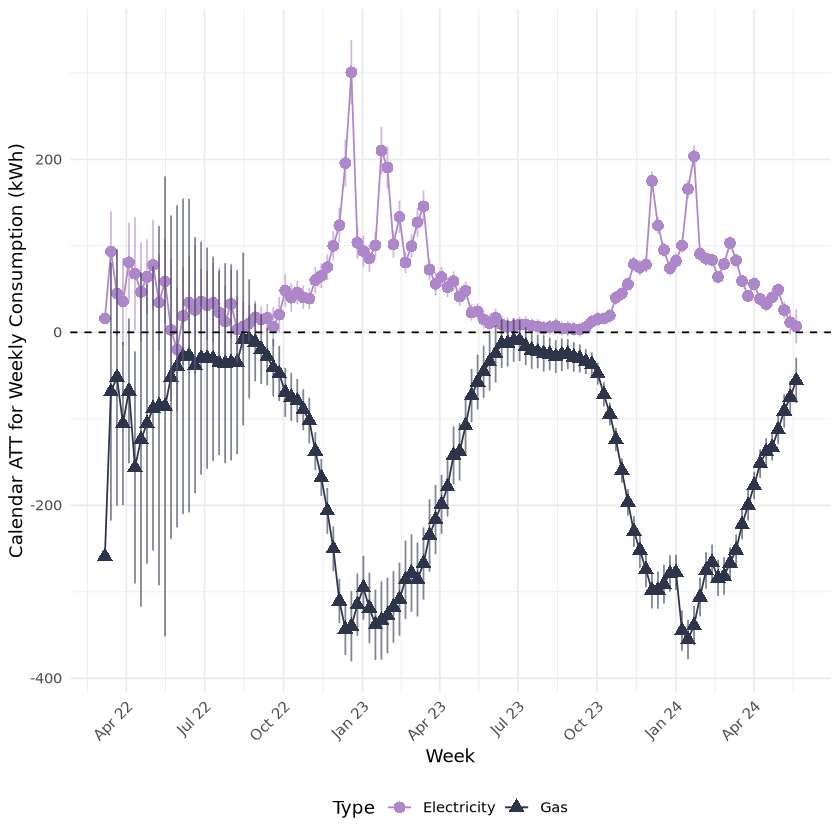

In [8]:
# Define the paths to the RDS files for electricity and gas
rds_files <- list(
  Overall =  "../data/scratch/est_cs_total_weekly.RDS",
  Electricity = "../data/scratch/est_cs_elec_weekly.RDS",
  Gas = "../data/scratch/est_cs_gas_weekly.RDS"
)

# define the start date
start_date <- min(overall_weekly$settlement_week)

# Load the data
elec_data <- aggte(readRDS(rds_files$Electricity), type = "calendar", na.rm = TRUE, clustervars = "id", bstrap = TRUE)
gas_data <- aggte(readRDS(rds_files$Gas), type = "calendar", na.rm = TRUE, clustervars = "id", bstrap = TRUE)

# Create the combined plot
# Extract estimates, standard errors, and event time for electricity
elec_estimates <- elec_data$att.egt/52.25
elec_standard_errors <- elec_data$se.egt/52.25
elec_event_time <- elec_data$egt

# Extract estimates, standard errors, and event time for gas
gas_estimates <- gas_data$att.egt/52.25
gas_standard_errors <- gas_data$se.egt/52.25
gas_event_time <- gas_data$egt

# Calculate the week dates based on the start_date
elec_week_dates <- start_date + weeks(elec_event_time)
gas_week_dates <- start_date + weeks(gas_event_time)

# Align the lengths of the data
max_length <- max(length(elec_estimates), length(gas_estimates))

elec_estimates <- c(elec_estimates, rep(NA, max_length - length(elec_estimates)))
elec_standard_errors <- c(elec_standard_errors, rep(NA, max_length - length(elec_standard_errors)))
elec_week_dates <- c(elec_week_dates, rep(NA, max_length - length(elec_week_dates)))

gas_estimates <- c(gas_estimates, rep(NA, max_length - length(gas_estimates)))
gas_standard_errors <- c(gas_standard_errors, rep(NA, max_length - length(gas_standard_errors)))
gas_week_dates <- c(gas_week_dates, rep(NA, max_length - length(gas_week_dates)))

# Create a data frame for plotting
plot_data <- data.frame(
  week_date = c(elec_week_dates, gas_week_dates),
  estimate = c(elec_estimates, gas_estimates),
  lower_ci = c(elec_estimates - 1.96 * elec_standard_errors, gas_estimates - 1.96 * gas_standard_errors),
  upper_ci = c(elec_estimates + 1.96 * elec_standard_errors, gas_estimates + 1.96 * gas_standard_errors),
  type = rep(c("Electricity", "Gas"), each = max_length)
)

# Define colors for electricity and gas
elec_color <- hp_color
gas_color <- not_hp_color

# Create the ggplot for combined effect
ggplot(plot_data, aes(x = as.Date(week_date), y = estimate, color = type)) +
  geom_point(aes(shape = type), size = 3) +  # Different shapes for Electricity and Gas
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  scale_x_date(
    labels = scales::date_format("%b %y"),  # Formatting months and years
    date_breaks = "3 month"  # Adjust this based on your data density
  ) +
  scale_colour_manual(name = "Type",
                      labels = c("Electricity", "Gas"),
                      values = c(Electricity = elec_color, Gas = gas_color)) +   
  scale_shape_manual(name = "Type",
                     labels =  c("Electricity", "Gas"),
                     values = c(16, 17)) + 
  labs(
    x = "Week",
    y = "Calendar ATT for Weekly Consumption (kWh)",
    color = "Type",
    shape = "Type"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom") + # Move the legend to the bottom
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for better readability

# Define the filename
file_name <- "../graphs/hp_calendarplot_combined.png"

# Save plot data to CSV
write.csv(plot_data, "../data/output/hp_calendarplot_combined.csv", row.names = FALSE)

# Save the plot
ggsave(file_name, device = "png", width = 8, height = 6, dpi = 300)

## DID Imputation package

In [5]:
install.packages("didimputation")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [43]:
# Required libraries
library(dplyr)
library(lubridate)
library(data.table)
library(didimputation)

# Data preparation (reusing your 'did_data' code)
start_date <- min(overall_weekly$settlement_week)
did_data <- overall_weekly %>%
  ungroup() %>%
  mutate(
    week = as.numeric(difftime(settlement_week, start_date, units = "weeks")) %/% 1 + 1,
    firstweek = as.numeric(difftime(installed_at, start_date, units = "weeks")) %/% 1 + 1
  ) %>%
  group_by(account_id) %>%
  mutate(id = cur_group_id()) %>%
  ungroup() %>%
  select(id, firstweek, week, total_consumption, elec_consumption, gas_consumption) %>%
  mutate(firstweek = ifelse(firstweek>131, NA, firstweek),
        total_consumption = total_consumption/ 52.25,
        elec_consumption= elec_consumption/ 52.25, 
        gas_consumption= gas_consumption/ 52.25, )

summary(did_data)


       id           firstweek          week        total_consumption
 Min.   :   1.0   Min.   : 12.0   Min.   :  1.00   Min.   :-1676.8  
 1st Qu.: 382.0   1st Qu.: 93.0   1st Qu.: 50.00   1st Qu.:  125.7  
 Median : 740.0   Median :115.0   Median : 83.00   Median :  234.4  
 Mean   : 783.1   Mean   :105.4   Mean   : 77.94   Mean   :  284.5  
 3rd Qu.:1140.0   3rd Qu.:125.0   3rd Qu.:109.00   3rd Qu.:  398.7  
 Max.   :1958.0   Max.   :131.0   Max.   :131.00   Max.   : 2524.3  
                  NA's   :40792                    NA's   :56660    
 elec_consumption  gas_consumption   
 Min.   :   0.00   Min.   :-1697.58  
 1st Qu.:  48.89   1st Qu.:   38.82  
 Median :  86.68   Median :  123.96  
 Mean   : 109.23   Mean   :  183.46  
 3rd Qu.: 146.49   3rd Qu.:  287.00  
 Max.   :1192.91   Max.   : 2395.07  
                   NA's   :56660     

In [56]:
# did_imputation command
# Setting up the arguments for did_imputation
imputation_results <- did_imputation(
  data = did_data,
  yname = "gas_consumption",    # Outcome variable (or choose "elec_consumption" or "gas_consumption")
  gname = "firstweek",            # Variable name for unit-specific treatment time
  tname = "week",                 # Calendar period
  idname = "id",                  # Unique unit ID
  first_stage = NULL,             # Default to unit and time fixed effects
  wname = NULL,                   # No weights provided
  wtr = NULL,                     # Treatment weights (for static and event study effects)
  horizon = c(-52, 52),                 # Use all event time horizons
  pretrends = -52:-1,               # Use all pre-trends
  cluster_var = "id"              # Clustering variable
)

# Viewing the results
summary(imputation_results)

     lhs                term              estimate          std.error     
 Length:172         Length:172         Min.   :-434.581   Min.   : 3.299  
 Class :character   Class :character   1st Qu.:-250.268   1st Qu.: 4.556  
 Mode  :character   Mode  :character   Median :-197.415   Median : 7.522  
                                       Mean   :-162.790   Mean   : 9.004  
                                       3rd Qu.:  -3.217   3rd Qu.:12.373  
                                       Max.   :  10.193   Max.   :20.626  
                                       NA's   :4          NA's   :4       
    conf.low          conf.high       
 Min.   :-446.223   Min.   :-422.939  
 1st Qu.:-269.036   1st Qu.:-226.855  
 Median :-219.855   Median :-174.288  
 Mean   :-180.438   Mean   :-145.142  
 3rd Qu.: -11.669   3rd Qu.:   5.227  
 Max.   :   1.326   Max.   :  19.059  
 NA's   :4          NA's   :4         

In [57]:
# did_imputation command
# Setting up the arguments for did_imputation
imputation_results2 <- did_imputation(
  data = did_data,
  yname = "elec_consumption",    # Outcome variable (or choose "elec_consumption" or "gas_consumption")
  gname = "firstweek",            # Variable name for unit-specific treatment time
  tname = "week",                 # Calendar period
  idname = "id",                  # Unique unit ID
  first_stage = NULL,             # Default to unit and time fixed effects
  wname = NULL,                   # No weights provided
  wtr = NULL,                     # Treatment weights (for static and event study effects)
  horizon = c(-52, 52),                 # Use all event time horizons
  pretrends = -52:-1,               # Use all pre-trends
  cluster_var = "id"              # Clustering variable
)

# Viewing the results
summary(imputation_results2)

     lhs                term              estimate         std.error     
 Length:172         Length:172         Min.   :-97.040   Min.   : 1.687  
 Class :character   Class :character   1st Qu.:  1.843   1st Qu.: 2.478  
 Mode  :character   Mode  :character   Median : 37.365   Median : 3.336  
                                       Mean   : 26.634   Mean   : 5.245  
                                       3rd Qu.: 52.370   3rd Qu.: 6.414  
                                       Max.   :112.292   Max.   :33.283  
    conf.low         conf.high      
 Min.   :-106.23   Min.   :-89.979  
 1st Qu.:  -3.30   1st Qu.:  6.858  
 Median :  23.68   Median : 49.929  
 Mean   :  16.35   Mean   : 36.915  
 3rd Qu.:  43.90   3rd Qu.: 60.656  
 Max.   :  80.27   Max.   :144.318  

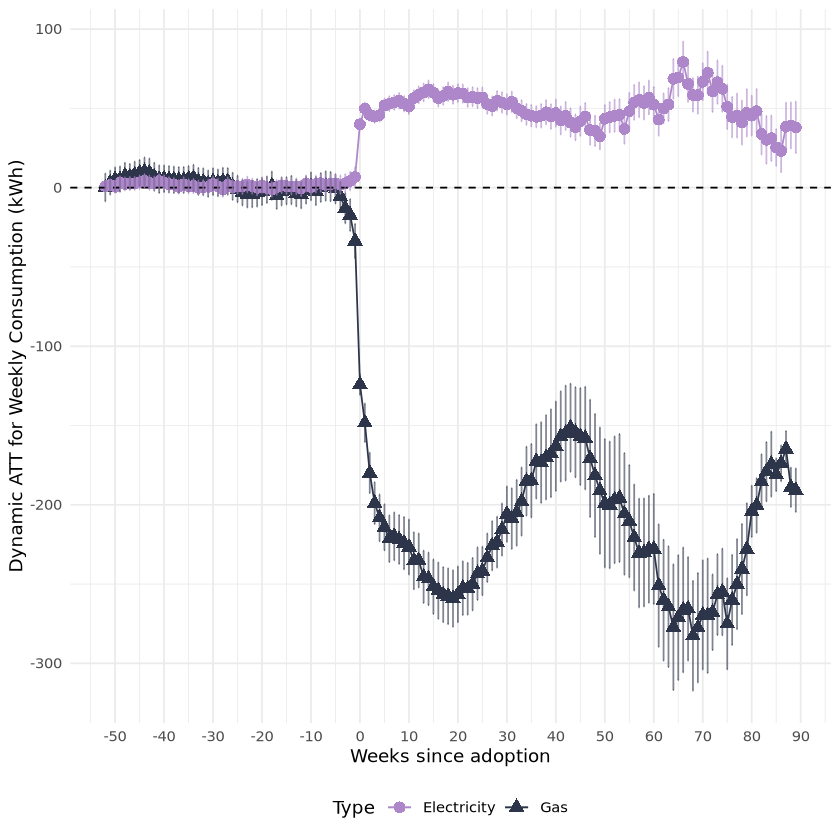

In [61]:
# merge the two estimates
plot_data <- rbind(imputation_results %>% mutate(type = "Gas"),
                   imputation_results2 %>% mutate(type = "Electricity")) %>%
rename(coefficient = estimate,
       event_time = term) %>%
mutate(event_time = as.numeric(event_time)) %>%
filter(event_time > -91, event_time < 90) %>%
mutate(lower_ci =  conf.low,
       upper_ci = conf.high)

#%>%
#mutate(lower_ci = ifelse(event_time < 0, NA, conf.low),
#       upper_ci = ifelse(event_time < 0, NA, conf.high))
                         

# define color
elec_color <- "#AD87CA"
gas_color <- "#2D354A"

# plot
ggplot(plot_data, aes(x = event_time, y = coefficient, group = type)) +
    geom_line(aes(color = type)) +
    geom_point(aes(color = type, shape = type), size = 3) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
    geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci, color = type), width = 0.2, alpha = 0.6) +
    scale_colour_manual(name = "Type",
                        labels = c("Electricity", "Gas"),
                        values = c(Electricity = elec_color, Gas = gas_color)) +   
    scale_shape_manual(name = "Type",
                       labels =  c("Electricity", "Gas"),
                       values = c(16, 17)) + 
    scale_x_continuous(breaks = seq(floor(min(plot_data$event_time) / 10) * 10, ceiling(max(plot_data$event_time) / 10) * 10, 10)) +
    labs(
      x = "Weeks since adoption",
      y = "Dynamic ATT for Weekly Consumption (kWh)"
    ) +
    theme_minimal() +
    theme(legend.position = "bottom")  # Move the legend to the bottom
ggsave("../graphs/hp_dynamic_att_combined_imputation.png", device = "png", width = 16, height = 12, dpi = 300)

In [62]:
imputation_results

lhs,term,estimate,std.error,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
gas_consumption,-52,0.1447614,4.463659,-8.60400984,8.893533
gas_consumption,-51,3.1933030,3.860716,-4.37369986,10.760306
gas_consumption,-50,5.1312389,3.889508,-2.49219651,12.754674
gas_consumption,-49,5.3790776,4.073992,-2.60594610,13.364101
gas_consumption,-48,7.4322346,4.236909,-0.87210661,15.736576
gas_consumption,-47,6.9560940,4.122422,-1.12385341,15.036041
gas_consumption,-46,8.1603868,4.211317,-0.09379517,16.414569
gas_consumption,-45,9.2944478,4.195758,1.07076180,17.518134
gas_consumption,-44,10.1926651,4.523773,1.32607049,19.059260
